# Shortest Path in a Grid with Obstacles Elimination
[Leetcode Link](https://leetcode.com/problems/shortest-path-in-a-grid-with-obstacles-elimination/description/)

You are given an m x n integer matrix grid where each cell is either 0 (empty) or 1 (obstacle). You can move up, down, left, or right from and to an empty cell in one step.

Return the minimum number of steps to walk from the upper left corner (0, 0) to the lower right corner (m - 1, n - 1) given that you can eliminate at most k obstacles. If it is not possible to find such walk return -1.

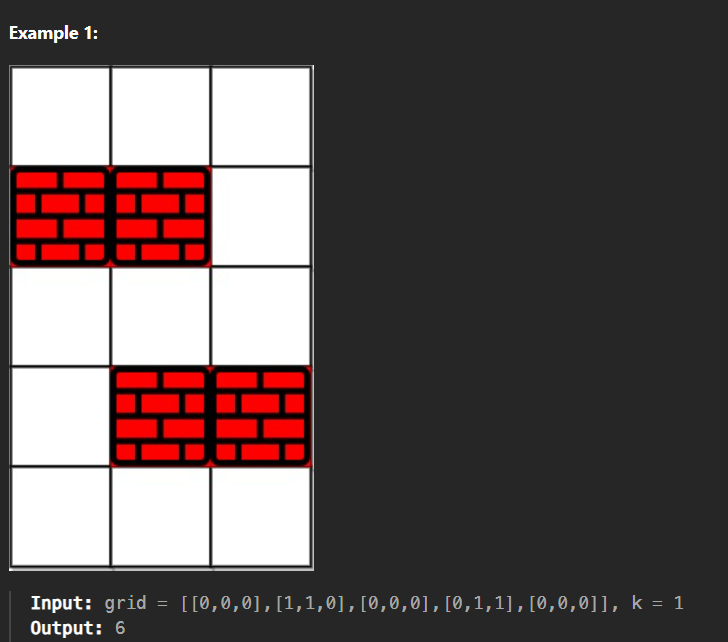

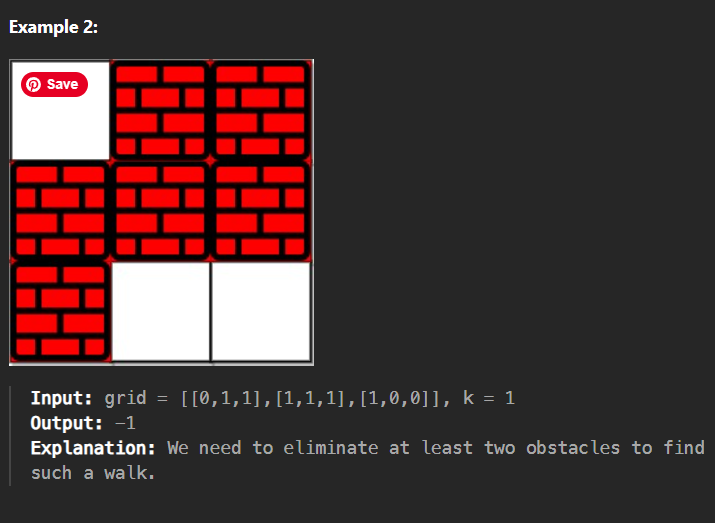

### Constraints
* m == grid.length
* n == grid[i].length
* 1 <= m, n <= 40
* 1 <= k <= m * n
* grid[i][j] is either 0 or 1.
* grid[0][0] == grid[m - 1][n - 1] == 0

## Approach 1: BFS

The solution will be very similar to the solution for the [Shortest Path Problem with no obstacle elimination](../x.Exercises.medium/ShortestPathBinaryMatrix.ipynb). We will do a breadth-first search starting at the top left corner. Instead of discarding neighbors that have a value of 1 in `grid`, we may add neighbors back to `cell_queue` if we have `k` to spare when we reach that neighbor. In order to determine that, we need to track how much `k` we have at that neighbor. So instead to storing coordinates `(row,col)` in `cell_queue`, we can store `k` values in that tuple. While we're at it, we can store `distance` values in that tuple to track that as well. So each entry in `cell_queue` will be in the format `(row,col,distance,curr_k)`. This means we're storing states of our search instead of just coordinates.

An issue we'll encounter is that we may need to traverse the same cell as we explore all possible paths. That's because different paths can arrive at the same cell with differing `curr_k` left. We need to be able to fully explore all these paths, but also not end up exploring the same path repeateded. So, we also need to augment `seen` to store states instead of just coordinates. Each entry in `seen` should now be in the format `(row, col, curr_k)`.

### Analysis
* Time Complexity: $O(m*n*k)$
    * we'll need to iterate through all the possible states as we explore the path to find the optimal solution
* Space Complexity: $O(m*n*k)$
    * the max possible values in `seen`

In [ ]:
from collections import deque
def shortestPath(grid: List[List[int]], k: int) -> int:
    steps= [(0,1),(0,-1),(1,0),(-1,0)]
    m = len(grid)
    n = len(grid[0])

    end = (m-1, n-1)
    cell_queue = deque([(0,0,0, k)])
    seen = {(0,0,k)}

    def valid_cell(r,c):
        if r<0 or r>=m or c<0 or c>=n:
            return False
        return True 

    while cell_queue:
        row,col,dist,curr_k = cell_queue.popleft()
        if row == end[0] and col == end[1]:
            return dist
        for step in steps:
            next_r = step[0] + row
            next_c = step[1] + col
            next_distance = dist + 1
            if not valid_cell(next_r,next_c):
                continue
            next_k = curr_k-1 if grid[next_r][next_c] == 1 else curr_k
            if next_k < 0:
                continue
            if (next_r,next_c,next_k) in seen:
                continue
            next_step = (next_r, next_c, next_distance, next_k)
            cell_queue.append(next_step)
            seen.add((next_r,next_c,next_k))
            

    return -1


        